<a href="https://colab.research.google.com/github/Yuliia-Safonova/melbourne-housing/blob/main/notebooks/melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Snapshot

## Частина 1. Організація роботи (Colab + GitHub)

**1.1. Створіть репозиторій**  

**1.2. Завантажте датасет з Kaggle**  

**1.3. Додайте датасет у репозиторій**  

**1.4. Отримайте RAW-посилання**  

**1.5. Робота в Colab і збереження назад у GitHub**

## Частина 2. Завдання покроково

### Крок 1. Завантаження даних


In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

In [165]:
# FILE_IN = "melb_data.csv"
FILE_IN = 'https://raw.githubusercontent.com/Yuliia-Safonova/melbourne-housing/refs/heads/main/data/melb_data.csv'

In [166]:
df_origin = pd.read_csv(FILE_IN)
df = df_origin.copy()

display(df.shape)

df.head()

(13580, 21)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


### Крок 2. Перший огляд

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [168]:
print("Data type:")
df.dtypes

Data type:


,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [169]:
df.describe().round(1)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.0,13580.0,13580.0,13580.0,13580.0,13580.0,13518.0,13580.0,7130.0,8205.0,13580.0,13580.0,13580.0
mean,2.9,1075684.1,10.1,3105.3,2.9,1.5,1.6,558.4,152.0,1964.7,-37.8,145.0,7454.4
std,1.0,639310.7,5.9,90.7,1.0,0.7,1.0,3990.7,541.0,37.3,0.1,0.1,4378.6
min,1.0,85000.0,0.0,3000.0,0.0,0.0,0.0,0.0,0.0,1196.0,-38.2,144.4,249.0
25%,2.0,650000.0,6.1,3044.0,2.0,1.0,1.0,177.0,93.0,1940.0,-37.9,144.9,4380.0
50%,3.0,903000.0,9.2,3084.0,3.0,1.0,2.0,440.0,126.0,1970.0,-37.8,145.0,6555.0
75%,3.0,1330000.0,13.0,3148.0,3.0,2.0,2.0,651.0,174.0,1999.0,-37.8,145.1,10331.0
max,10.0,9000000.0,48.1,3977.0,20.0,8.0,10.0,433014.0,44515.0,2018.0,-37.4,145.5,21650.0


In [170]:
display(df.describe(include='all'))

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
count,13580,13580,13580.000000,13580,1.358000e+04,13580,13580,13580,13580.000000,13580.000000,...,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,12211,13580.000000,13580.000000,13580,13580.000000
unique,314,13378,NaN,3,NaN,5,268,58,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33,NaN,NaN,8,NaN
top,Reservoir,5 Margaret St,NaN,h,NaN,S,Nelson,27/05/2017,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Moreland,NaN,NaN,Southern Metropolitan,NaN
freq,359,3,NaN,9449,NaN,9022,1565,473,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1163,NaN,NaN,4695,NaN
mean,NaN,NaN,2.937997,NaN,1.075684e+06,NaN,NaN,NaN,10.137776,3105.301915,...,1.534242,1.610075,558.416127,151.967650,1964.684217,NaN,-37.809203,144.995216,NaN,7454.417378
std,NaN,NaN,0.955748,NaN,6.393107e+05,NaN,NaN,NaN,5.868725,90.676964,...,0.691712,0.962634,3990.669241,541.014538,37.273762,NaN,0.079260,0.103916,NaN,4378.581772
min,NaN,NaN,1.000000,NaN,8.500000e+04,NaN,NaN,NaN,0.000000,3000.000000,...,0.000000,0.000000,0.000000,0.000000,1196.000000,NaN,-38.182550,144.431810,NaN,249.000000
25%,NaN,NaN,2.000000,NaN,6.500000e+05,NaN,NaN,NaN,6.100000,3044.000000,...,1.000000,1.000000,177.000000,93.000000,1940.000000,NaN,-37.856822,144.929600,NaN,4380.000000
50%,NaN,NaN,3.000000,NaN,9.030000e+05,NaN,NaN,NaN,9.200000,3084.000000,...,1.000000,2.000000,440.000000,126.000000,1970.000000,NaN,-37.802355,145.000100,NaN,6555.000000
75%,NaN,NaN,3.000000,NaN,1.330000e+06,NaN,NaN,NaN,13.000000,3148.000000,...,2.000000,2.000000,651.000000,174.000000,1999.000000,NaN,-37.756400,145.058305,NaN,10331.000000


In [171]:
print('Missing values:\n')
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_report = pd.DataFrame({
    'count': missing,
    'type': df.dtypes.astype(str),
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,type,%
BuildingArea,6450,float64,47.5
Car,62,float64,0.5
CouncilArea,1369,object,10.1
YearBuilt,5375,float64,39.6


### Крок 3. Очищення

In [172]:
# Перейменування колонок

print('Rename columns:\n')

df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Suburb': 'suburb',
    'Address': 'address',
    'Rooms': 'rooms',
    'Type': 'type',
    'Price': 'price',
    'Method': 'method',
    'SellerG': 'seller',
    'Date': 'date',
    'Distance': 'distance',
    'Postcode': 'postcode',
    'Bedroom2': 'bedrooms',
    'Bathroom': 'bathrooms',
    'Car': 'car_spaces',
    'Landsize': 'land_size',
    'BuildingArea': 'building_area',
    'YearBuilt': 'year_built',
    'CouncilArea': 'council_area',
    'Lattitude': 'latitude',
    'Longtitude': 'longitude',
    'Regionname': 'region_name',
    'Propertycount': 'property_count'
})

print(list(df.columns))

Rename columns:

['suburb', 'address', 'rooms', 'type', 'price', 'method', 'seller', 'date', 'distance', 'postcode', 'bedrooms', 'bathrooms', 'car_spaces', 'land_size', 'building_area', 'year_built', 'council_area', 'latitude', 'longitude', 'region_name', 'property_count']


In [173]:
clean = df.copy() # копія датасета

# Видалення технічного стовпця
if 'Unnamed: 0' in clean.columns:
    clean = clean.drop(columns='Unnamed: 0')

# Перетворення дати
clean['date'] = pd.to_datetime(clean['date'], dayfirst=True)

# Заміна хибних нулів на NaN
clean.loc[clean['land_size'] == 0, 'land_size'] = np.nan
clean.loc[clean['building_area'] == 0, 'building_area'] = np.nan

# Перевірка року побудови
clean.loc[clean['year_built'] < 1900, 'year_built'] = np.nan

# Перевірка дублікатів
print('Duplicates:', clean.duplicated().sum())  # в нашому випадку 0 дублікатів
clean = clean.drop_duplicates()                 # якщо були б дублікати, прибираємо їх

# Перевіряємо розмір після чищення
print('Shape after cleaning:', clean.shape)

Duplicates: 0
Shape after cleaning: (13580, 21)


### Крок 4. Дослідження (EDA)

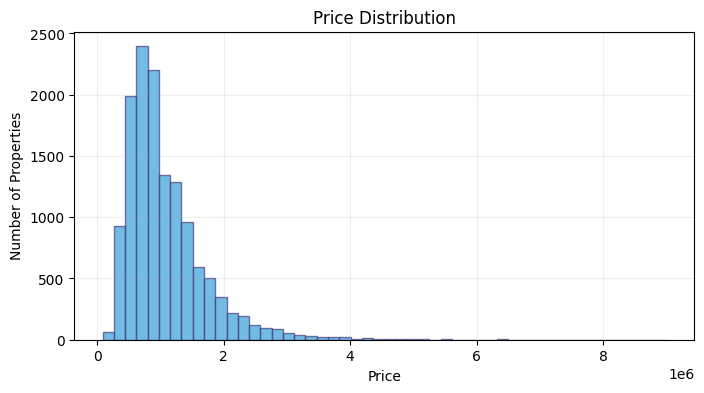

In [174]:
# Розподіл ціни

plt.figure(figsize=(8, 4))

plt.hist(clean['price'], bins=50, color='#379fdb', edgecolor='#473c7a', alpha=0.7)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of Properties')
plt.grid(axis='y', alpha=0.2)
plt.grid(axis='x', alpha=0.2)

plt.show()

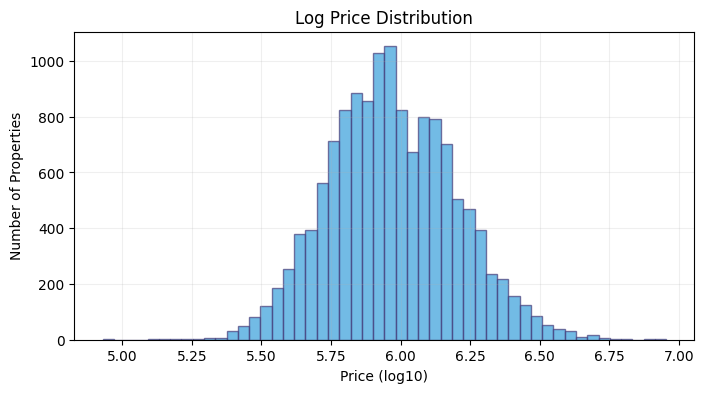

In [175]:
# Логарифм ціни

plt.figure(figsize=(8, 4))

plt.hist(np.log10(clean['price']), bins=50, color='#379fdb', edgecolor='#473c7a', alpha=0.7)

plt.title('Log Price Distribution')
plt.xlabel('Price (log10)')
plt.ylabel('Number of Properties')
plt.grid(axis='y', alpha=0.2)
plt.grid(axis='x', alpha=0.2)

plt.show()

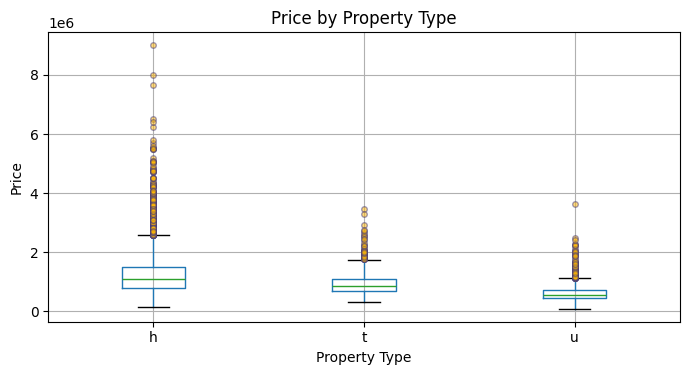

In [176]:
# Ціна за типом житла

fig, ax = plt.subplots(figsize=(7, 4))

clean.boxplot(
    column='price',
    by='type',
    ax=ax,
    flierprops=dict(
        marker='o',
        markerfacecolor='#ffb703',
        markeredgecolor='#473c7a',
        markersize=4,
        alpha=0.5
    )
)

ax.set_title('Price by Property Type')
ax.set_xlabel('Property Type')
ax.set_ylabel('Price')

plt.suptitle('')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

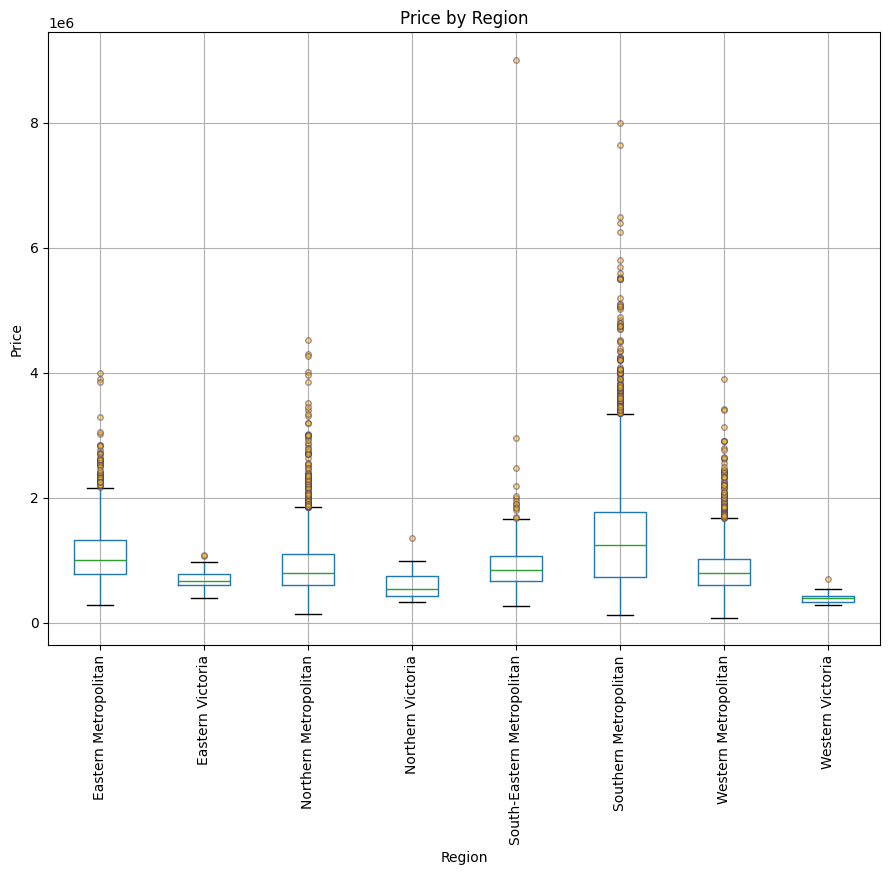

In [177]:
# Ціна за регіоном

fig, ax = plt.subplots(figsize=(9, 9))

clean.boxplot(
    column='price',
    by='region_name',
    ax=ax,
    flierprops=dict(
        marker='o',
        markerfacecolor='#ffb703',
        markeredgecolor='#473c7a',
        markersize=4,
        alpha=0.5
    )
)

ax.set_title('Price by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Price')

plt.suptitle('')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [194]:
# Кореляція числових ознак із ціною

num = clean.select_dtypes(include='number')

corr_price = (
    num.corr()['price']
       .drop('price')
       .sort_values(key=abs, ascending=False)
).round(2)

print('Correlation of Features with Price:\n')
print(corr_price)
print()

Correlation of Features with Price:

rooms             0.50
bedrooms          0.48
bathrooms         0.47
year_built       -0.29
car_spaces        0.24
latitude         -0.21
longitude         0.20
distance         -0.16
postcode          0.11
building_area     0.09
property_count   -0.04
land_size         0.02
Name: price, dtype: float64



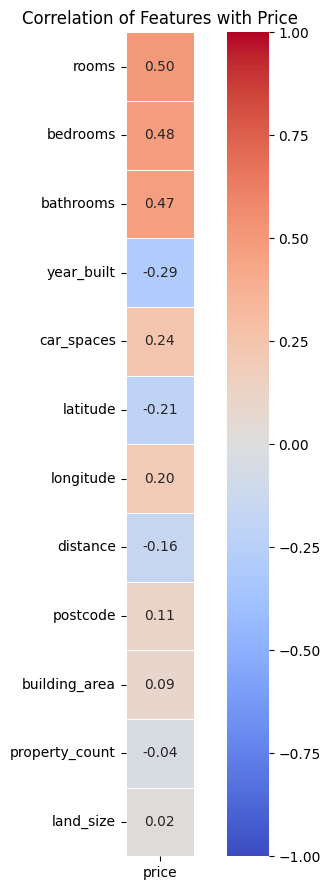

In [195]:
# Heatmap кореляцій

fig, ax = plt.subplots(figsize=(7, 9))

sns.heatmap(
    corr_price.to_frame(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 10}
)

ax.set_title('Correlation of Features with Price')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [180]:
# Пошук ознак, які дублюють одна одну

display(num.corr().round(2))

,rooms,price,distance,postcode,bedrooms,bathrooms,car_spaces,land_size,building_area,year_built,latitude,longitude,property_count
rooms,1.00,0.50,0.29,0.06,0.94,0.59,0.41,0.00,0.12,-0.07,0.02,0.10,-0.08
price,0.50,1.00,-0.16,0.11,0.48,0.47,0.24,0.02,0.09,-0.29,-0.21,0.20,-0.04
distance,0.29,-0.16,1.00,0.43,0.30,0.13,0.26,0.01,0.10,0.19,-0.13,0.24,-0.05
postcode,0.06,0.11,0.43,1.00,0.06,0.11,0.05,0.03,0.06,0.04,-0.41,0.45,0.06
bedrooms,0.94,0.48,0.30,0.06,1.00,0.58,0.41,0.00,0.12,-0.06,0.02,0.10,-0.08
bathrooms,0.59,0.47,0.13,0.11,0.58,1.00,0.32,0.03,0.11,0.18,-0.07,0.12,-0.05
car_spaces,0.41,0.24,0.26,0.05,0.41,0.32,1.00,0.02,0.10,0.07,-0.00,0.06,-0.02
land_size,0.00,0.02,0.01,0.03,0.00,0.03,0.02,1.00,0.50,0.07,0.01,0.01,-0.00
building_area,0.12,0.09,0.10,0.06,0.12,0.11,0.10,0.50,1.00,0.03,0.04,-0.02,-0.03
year_built,-0.07,-0.29,0.19,0.04,-0.06,0.18,0.07,0.07,0.03,1.00,0.06,-0.02,0.01


In [181]:
clean[['rooms', 'bedrooms']].corr()

,rooms,bedrooms
rooms,1.00000,0.94419
bedrooms,0.94419,1.00000


**Висновки**

1. Найдорожчим типом житла є будинки (type = 'h'), а також об’єкти в регіоні Southern Metropolitan. За boxplot видно, що медіанна ціна будинків вища, ніж у таунхаусів (t) та квартир (u). Регіон Southern Metropolitan також має найбільший розкид цін і багато високих викидів, що свідчить про наявність преміального сегменту нерухомості.  

2. Найсильніше з вартістю житла пов’язані кількість кімнат (rooms), кількість ванних кімнат (bathrooms) та кількість спалень (bedrooms). Кореляції за цими змінними знаходяться приблизно на рівні 0.47–0.50, що свідчить про позитивний зв’язок: зі збільшенням кількості кімнат ціна зростає. Ознаки rooms і bedrooms мають дуже високу кореляцію між собою, тому вони частково дублюють інформацію і це потрібно врахувати під час побудови моделі.  

3. Відстань до центру (distance) має слабкий негативний зв’язок (= -0.16), тобто житло, розташоване далі від центру, у середньому трохи дешевше, але залежність не є вираженою.  

4. Також помітний від’ємний зв’язок із роком побудови (year_built = -0.29). Це означає, що більш нові будинки в середньому дорожчі, хоча цей зв’язок не є дуже сильним.  

5. Інші ознаки, такі як площа ділянки (land_size), кількість парковочних місць (car_spaces), координати (latitude, longitude), а також (property_count, postcode), мають слабкий або майже відсутній лінійний зв’язок із ціною.